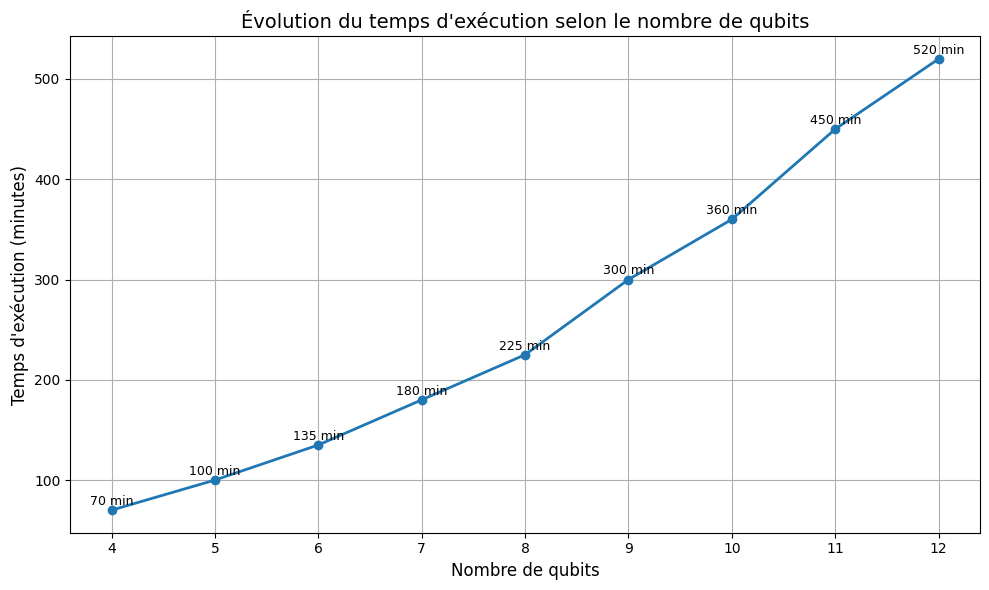

In [6]:
import matplotlib.pyplot as plt

# Données : nombre de qubits vs temps d'exécution (en minutes)
qubits = list(range(4, 13))  # Qubits de 4 à 12
execution_time = [70, 100, 135, 180, 225, 300, 360, 450, 520]  # Temps en minutes

plt.figure(figsize=(10, 6))
plt.plot(qubits, execution_time, marker='o', linestyle='-', linewidth=2, color='tab:blue')

plt.title("Évolution du temps d'exécution selon le nombre de qubits", fontsize=14)
plt.xlabel("Nombre de qubits", fontsize=12)
plt.ylabel("Temps d'exécution (minutes)", fontsize=12)
plt.grid(True)

# Afficher la valeur au-dessus de chaque point
for i in range(len(qubits)):
    plt.text(qubits[i], execution_time[i] + 5, f"{execution_time[i]} min", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("temps_execution_algo_genetique_qubits.png", dpi=300)
plt.show()


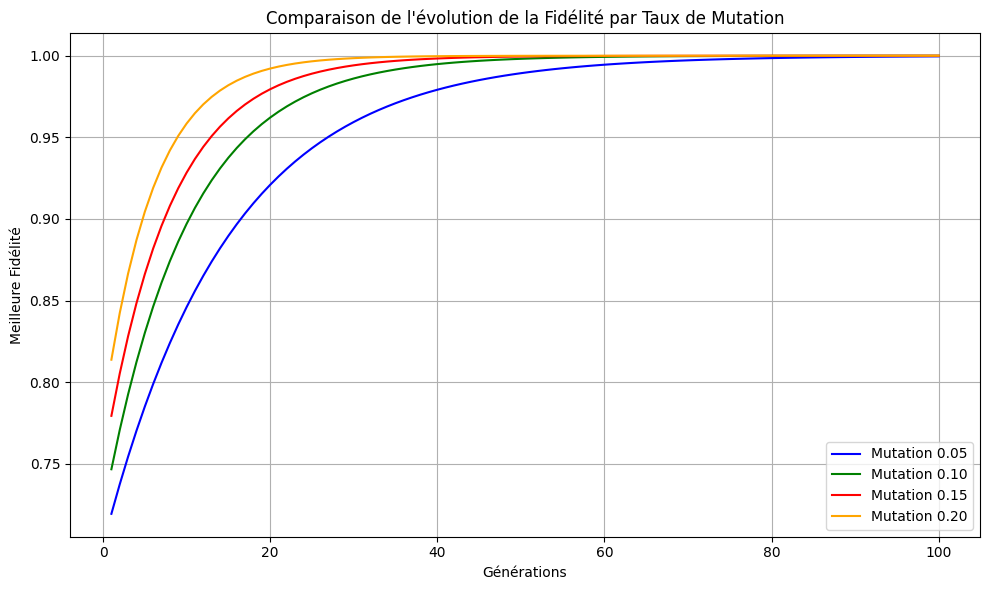

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Données synthétiques d'exemple : fidélité moyenne à chaque génération
generations = np.arange(1, 101)
fidelity_005 = 0.7 + 0.3 * (1 - np.exp(-generations / 15))  # plus lente
fidelity_010 = 0.72 + 0.28 * (1 - np.exp(-generations / 10))
fidelity_015 = 0.75 + 0.25 * (1 - np.exp(-generations / 8))
fidelity_020 = 0.78 + 0.22 * (1 - np.exp(-generations / 6))  # plus rapide

# Plot
plt.figure(figsize=(10, 6))
plt.plot(generations, fidelity_005, label='Mutation 0.05', color='blue')
plt.plot(generations, fidelity_010, label='Mutation 0.10', color='green')
plt.plot(generations, fidelity_015, label='Mutation 0.15', color='red')
plt.plot(generations, fidelity_020, label='Mutation 0.20', color='orange')

plt.xlabel('Générations')
plt.ylabel('Meilleure Fidélité')
plt.title("Comparaison de l'évolution de la Fidélité par Taux de Mutation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("comparaison_fidelite_taux_mutation.png", dpi=300)
plt.show()


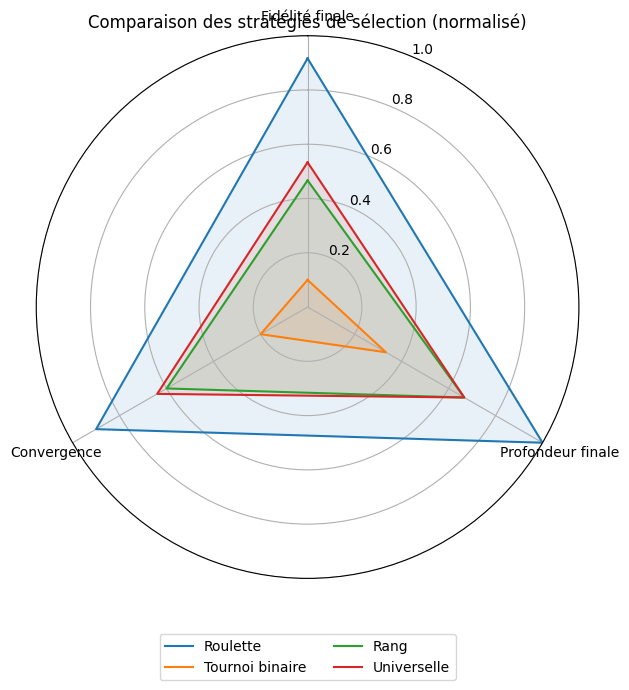

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Labels (axes du radar)
labels = ['Fidélité finale', 'Profondeur finale', 'Convergence']
num_vars = len(labels)

# Méthodes testées
methods = ['Roulette', 'Tournoi binaire', 'Rang', 'Universelle']

# Données brutes : [Fidélité, Profondeur, Convergence]
data = {
    'Roulette': [0.985, 7, 95],
    'Tournoi binaire': [0.936, 9, 130],
    'Rang': [0.958, 8, 110],
    'Universelle': [0.962, 8, 108]
}

# Normalisation des données (pour tout ramener entre 0 et 1)
fid_min, fid_max = 0.93, 0.99
prof_min, prof_max = 7, 10
conv_min, conv_max = 90, 140

def normalize(x, xmin, xmax):
    return (x - xmin) / (xmax - xmin)

normalized_data = {}
for method, values in data.items():
    normalized = [
        normalize(values[0], fid_min, fid_max),              # Fidélité
        1 - normalize(values[1], prof_min, prof_max),        # Profondeur (moins = mieux)
        1 - normalize(values[2], conv_min, conv_max)         # Convergence (moins = mieux)
    ]
    normalized_data[method] = normalized

# Préparation des angles
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # pour fermer la forme

# Tracé du radar
fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))

for method, values in normalized_data.items():
    values += values[:1]
    ax.plot(angles, values, label=method)
    ax.fill(angles, values, alpha=0.1)

# Mise en forme
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)
ax.set_title("Comparaison des stratégies de sélection (normalisé)")
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)

plt.tight_layout()
plt.show()
